# Grilla de ejemplos: números (0-9)

Muestra (y guarda) una grilla con UN ejemplo de imagen por cada número presente en `data/asl_dataset/`, con el nombre de la clase como título de cada celda.


In [1]:
import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Ajustá esta ruta si el notebook no está en la carpeta notebooks/ de la raíz del proyecto
DATASET_DIR = Path("../data/asl_dataset")
OUTPUT_PATH = Path("img/numbers_grid.png")
COLS = 6


In [2]:
def one_example_per_class(dataset_dir: Path, class_filter):
    """
    Recorre las subcarpetas de dataset_dir, se queda solo con las que
    cumplen class_filter(nombre_carpeta), y devuelve un dict
    {nombre_clase: ruta_a_una_imagen_de_ejemplo}.
    """
    examples = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        if not class_filter(class_dir.name):
            continue

        images = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        if images:
            examples[class_dir.name] = images[0]

    return examples


def plot_grid(examples: dict, title: str, output_path: Path, cols: int = 6, numeric_sort: bool = False):
    """
    Dibuja una grilla de imágenes, una por clase, y la guarda en
    output_path además de mostrarla.
    """
    labels = sorted(examples.keys(), key=int) if numeric_sort else sorted(examples.keys())
    n = len(labels)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, label in zip(axes, labels):
        img_bgr = cv2.imread(str(examples[label]))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(label, fontsize=14, fontweight="bold")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()

    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Grilla guardada en: {output_path}")

    plt.show()


Números encontrados: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Grilla guardada en: img\numbers_grid.png


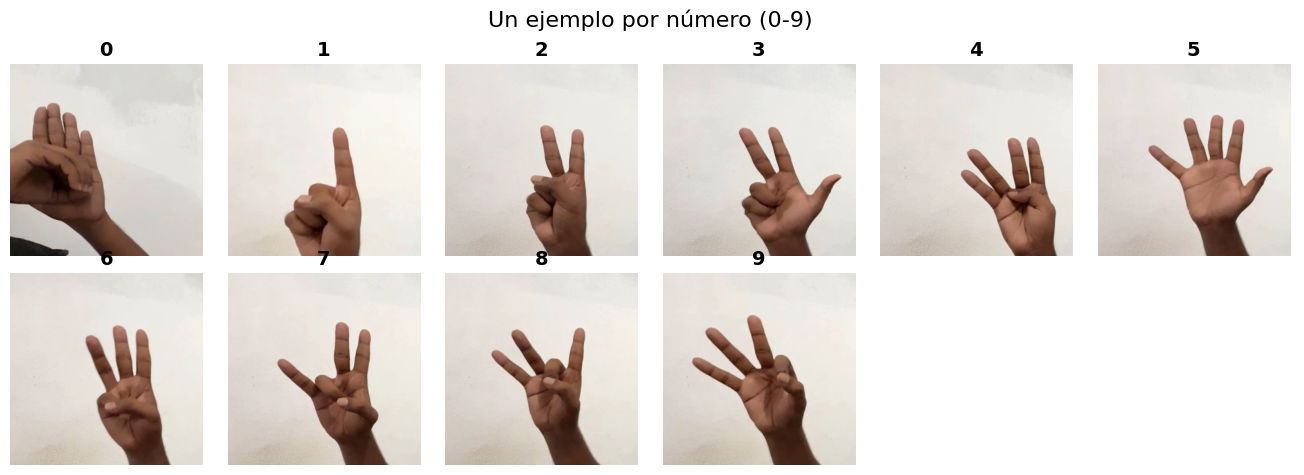

In [3]:
number_examples = one_example_per_class(
    DATASET_DIR,
    class_filter=lambda name: name.isdigit(),
)

print(f"Números encontrados: {sorted(number_examples.keys(), key=int)}")

plot_grid(
    number_examples,
    title="Un ejemplo por número (0-9)",
    output_path=OUTPUT_PATH,
    cols=COLS,
    numeric_sort=True,
)
